In [6]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
import warnings
warnings.filterwarnings('ignore', category=IntegrationWarning)
kpc = const.kpc.cgs.value

def SB(z, radius_kpc, emissivity, dr):
    r_min, r_max = radius_kpc.min(), radius_kpc.max()
    Project_R = np.linspace(0, 100, 70) * kpc
    N = len(Project_R)
    surface_brightness = np.zeros(N)
    Lumin = np.zeros(N)

    from scipy.interpolate import interp1d
    emis_interp = interp1d(radius_kpc, emissivity, bounds_error=False, fill_value=0)
    
    for ii, R in enumerate(Project_R):
        # 적분 함수 정의
        def integrand(r):
            if r < R:
                return 0
            else:
                emis = emis_interp(r)
                return emis * r / np.sqrt(r**2 - R**2)
            
        surface_brightness[ii], _ = quad(integrand, R, r_max)
        surface_brightness[ii] *= 2 / (1+z)**4
    dR =  Project_R[1] - Project_R[0]    
    def lumin_integrand(R):
        if R == 0 :
            area = np.pi * (0.5*dR)**2
        elif R == r_max:
            area = np.pi * (2*R +0.5*dR)*0.5*dR 
        else:
            area = 2 * np.pi * R * np.interp(R, Project_R, surface_brightness)
        
        return area
    
    Lumin, _ = quad(lumin_integrand, 0, r_max)
    
    return Project_R / kpc, surface_brightness, Lumin



def read_file(path_way, atom):
    Mod = pc.CloudyModel(path_way, cloudy_version_major=23)
    Mod.ionic_names

    N_H = sum(Mod.dr*Mod.nH)
    # solar_metallicity
    frac_He =1.00E-01
    frac_C = 2.45E-04
    frac_O = 4.90E-04
    frac_N = 8.51E-05
    frac_Mg = 3.47E-05


    N_HI = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',0))
    N_HII = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',1))
    N_HeII = frac_He*sum(Mod.dr*Mod.nH*Mod.get_ionic('He',1))
    N_OVI = frac_O*sum(Mod.dr*Mod.nH*Mod.get_ionic('O',5))
    N_NV = frac_N*sum(Mod.dr*Mod.nH*Mod.get_ionic('N',4))
    N_CIV = frac_C*sum(Mod.dr*Mod.nH*Mod.get_ionic('C',3))

    num = len(Mod.nH)
    r_CIV = path_way +  '.ele_C'
    f = open(r_CIV,'r')
    header = f.readline()
    CIV_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[4])
        CIV_frac[i] = j
        i = i + 1

    r_He = path_way +  '.ele_He'
    f = open(r_He,'r')
    header = f.readline()
    HeII_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[2])
        HeII_frac[i] = j
        i = i + 1




    n_H= Mod.nH
    n_He = n_H*frac_He
    n_C = n_H*frac_C
    nden_CIV = CIV_frac*n_C
    nden_HeII = HeII_frac*n_He

    # print('Lya Luminosity = ',float(Mod.get_emis_vol('H__1_121567A')) )
    # print('HeII Luminosity = ',float(Mod.get_emis_vol('HE_2_164043A')) )
    # print('CIV Luminosity = ',float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A')) )

    if atom == 'CIV':
        Cloudy_Lum = float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A'))
        Cloudy_emis = (Mod.get_emis('C__4_154819A')) + (Mod.get_emis('C__4_155078A'))
        Cloudy_den = nden_CIV
    elif atom == 'Lya':
        Cloudy_Lum= float(Mod.get_emis_vol('H__1_121567A'))
        Cloudy_emis = Mod.get_emis('H__1_121567A')
        Cloudy_den = n_H
    elif atom == 'HeII':
        Cloudy_Lum = float(Mod.get_emis_vol('HE_2_164043A'))
        Cloudy_emis = Mod.get_emis('HE_2_164043A')
        Cloudy_den = nden_HeII
    return Cloudy_Lum , Cloudy_emis ,Cloudy_den

def radius(path, atom):
    Mod = pc.CloudyModel(path, cloudy_version_major=23)
    radius = Mod.radius/kpc
    radius_kpc =Mod.radius 
    dr = Mod.dr 
    return radius, radius_kpc, dr

def make_data_file(path,atom):
    lum ,emis ,den = read_file(path,atom)
    radius_R , radius_kpc , dr=  radius(path,atom)
    tt =  pd.DataFrame(np.column_stack((radius_R,emis,den)))
    tt.to_csv('/home/jin/RT/RT_main/{}_cloudy.txt'.format(atom), sep='\t',index=False,header =False)
    tt.to_csv('/home/jin/RT/RT_scat/{}_cloudy.txt'.format(atom), sep='\t',index = False,header=False)
    return print("make data file!")





def SB(z, radius_kpc, emissivity, dr):
    r_min, r_max = radius_kpc.min(), radius_kpc.max()
    Project_R = np.linspace(0, 100, 70) * kpc
    N = len(Project_R)
    surface_brightness = np.zeros(N)
    Lumin = np.zeros(N)

    from scipy.interpolate import interp1d
    emis_interp = interp1d(radius_kpc, emissivity, bounds_error=False, fill_value=0)
    
    for ii, R in enumerate(Project_R):
        # 적분 함수 정의
        def integrand(r):
            if r < R:
                return 0
            else:
                emis = emis_interp(r)
                return emis * r / np.sqrt(r**2 - R**2)
            
        surface_brightness[ii], _ = quad(integrand, R, r_max)
        surface_brightness[ii] *= 2 / (1+z)**4
    dR =  Project_R[1] - Project_R[0]    
    def lumin_integrand(R):
        if R == 0 :
            area = np.pi * (0.5*dR)**2
        elif R == r_max:
            area = np.pi * (2*R +0.5*dR)*0.5*dR 
        else:
            area = 2 * np.pi * R * np.interp(R, Project_R, surface_brightness)
        
        return area
    
    Lumin, _ = quad(lumin_integrand, 0, r_max)
    
    return Project_R / kpc, surface_brightness, Lumin

def Column_Density(radius_kpc, number_density):
    r_min, r_max = radius_kpc.min(), radius_kpc.max()
    Project_R = np.linspace(0, 100, 70) * kpc
    N = len(Project_R)
    column_density = np.zeros(N)
    Lumin = np.zeros(N)

    from scipy.interpolate import interp1d
    colden_interp = interp1d(radius_kpc, number_density, bounds_error=False, fill_value=0)
    
    for ii, R in enumerate(Project_R):
        # 적분 함수 정의
        def integrand(r):
            if r < R:
                return 0
            else:
                colden = colden_interp(r)
                return colden * r / np.sqrt(r**2 - R**2)
            
        column_density[ii], _ = quad(integrand, R, r_max)

    return Project_R / kpc, column_density




def RT_SB(path):
    name = ['radius','SB_K','SB_H','SB_tot','1','2','3']
    data_sp = pd.read_csv(path, sep='\s+', header=None,names=name)
    rad, SB_t, SB_k,SB_h =  data_sp['radius'].to_numpy(),data_sp['SB_tot'].to_numpy(),data_sp['SB_K'].to_numpy(),data_sp['SB_H'].to_numpy()
    return rad*100, rad*100*kpc, SB_t 

def find_y(x_find,x,y):
    ii = int(np.where(x <= x_find)[0][-1])
    # print(ii)
    y_find = (y[ii+1] -y[ii]) / (x[ii+1] - x[ii])*(x_find - x[ii]) + y[ii]
    return y_find




warnings.filterwarnings("ignore", category=IntegrationWarning)

path_LT = r'/home/jin/RT/RT_main/data_CLOUDY_setting/OTS_n_LT_y/CIV_Lumin_42' # no OTS , yes LT For CIV

RT_path_HeII =r'/home/jin/RT/RT_main/data_HeII_wo_s/N_atom000E+00_Vexp000E+00_Vemit000E+00_tauD000E+00_Vran000E+00radi.dat'
RT_path_CIV = r'/home/jin/RT/RT_main/data_CIV_wo_s/N_atom000E+00_Vexp000E+00_Vemit000E+00_tauD000E+00_Vran000E+00radi.dat'


rr = np.arange(12, 18, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952

lam_c =  (C_IV_K_A + C_IV_H_A) / 2

voigt_path_11_8 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_11_8.txt'
voigt_path_30 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_30.txt'
voigt_path_50 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_50.txt'

NN = int(1e4)


C_IV_N = np.linspace(1e12, 1e17, NN)

def N_esc_scat(line,voigt_path,v_th):


    name = ['lambda','sigma']
    voigt_file = pd.read_csv(voigt_path,sep='\s+',names=name,)
    lam_0, scat_0 = voigt_file['lambda'].to_numpy() , voigt_file['sigma'].to_numpy()

    del_V =  ((lam_0-C_IV_K) / C_IV_K) * cc /1e5
    x =   del_V / (v_th/1e5)
    K_H_center = 250  / (v_th/1e5)
    dx = x[1] - x[0]
    x_K = x[np.where(x <= K_H_center)[0]]
    x_H = x[np.where(x >= K_H_center)[0]]
    scat_K = scat_0[np.where(x <= K_H_center)[0]]
    scat_H = scat_0[np.where(x >= K_H_center)[0]]
    x_0 = np.zeros(NN)

    xx_K = 0
    xx_H = 500/ (v_th/1e5)

    if line =='K' or line =='k' :
        x = x_K
        scat = scat_K
        xx_c = xx_K
        ii = np.where( (x > -dx/2) & (x < dx/2) )[0]
        cross_sec_cen, N_CIV_cen =  (scat[ii]) ,1/scat[ii]

    elif line == 'H' or line =='h' :
        x = x_H 
        scat = scat_H
        xx_c = xx_H
        jj = np.where( (x > xx_H -dx/2) & (x < xx_H +dx/2) )[0]
        cross_sec_cen, N_CIV_cen =  (scat[jj]) ,1/scat[jj]



    tau_profile = np.outer(C_IV_N, scat)
    
    # print(line,'scattering cross-section = ', cross_sec_cen )
    print(line,'Center  Columne density = ', N_CIV_cen  )


    for ii, jj in enumerate(C_IV_N):
        x_p = np.where(np.diff(np.sign(1 - tau_profile[ii, :])))[0]
        x_0[ii] = x[x_p].max() if x_p.size > 0 else 0


    V_del_peak = 2*abs( (x_0 - xx_c)*(v_th/1e5))

    del_lam_D = v_th / C_IV_K
    nu_0_K= cc/C_IV_K
    nu_esc = x_0*del_lam_D + nu_0_K
    # V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
    v_esc = x_0*v_th
    N_esc= 1/special.erfc(v_esc/v_th)

    
    return x ,tau_profile , V_del_peak , N_esc


def calculate_order_and_value(value):

    if value == 0 :
        return "000" , 0
    elif value == 1:
        return int(value * 100), 0
    elif value < 100:
        return int(value * 10), 1
    elif value < 1000:
        return int(value), 2
    else :
        return int(value / 10), 3


#combine K and H lines
def data_sp_com(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    lam = data[0].to_numpy()
    spec_tot = data[1].to_numpy() # total photon
    spec_sc = data[2].to_numpy()  # scattering photon
   # spec_pol_tot = data[3]  # polization of the total photon
   # spec_pol_scat = data[4]  $ polization of the scattering photon
    return lam , spec_tot , spec_sc



#separate K and H line
def data_sp(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    x = data[0].to_numpy()
    if Line == 'h' or Line =='H':
        lam = -  C_IV_H_A / ( (vran/cc_k)*x -1)
        spec_tot = data[2].to_numpy()
        spec_scat = data[4].to_numpy()

    elif Line == 'k' or Line =='K':
        lam = - C_IV_K_A / ( (vran/cc_k)*x -1)
        spec_tot = data[1].to_numpy()
        spec_scat = data[3].to_numpy()       

    
    return lam , spec_tot , spec_scat


def data_scat(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}_f_esc.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)

    if Line == 'k' or Line =='K':
        N_sct = data.iloc[0,4]

    elif Line == 'h' or Line =='H':
        N_sct = data.iloc[0,5]

    return N_sct
    


def K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran):
    lam , spec_tot , spec_halo =  data_sp_com(Line , atom_num , atom_index, vout, vemit, vran)
    if Line == 'k' or Line =='K':
        ioc = np.where(lam<=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]

    elif Line == 'h' or Line =='H':
        ioc = np.where(lam>=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]
    else :
        lam_x  = lam 
        spec_tot_x = spec_tot
        spec_halo_x = spec_halo

    return lam_x , spec_tot_x , spec_halo_x

lam, spec_tot , spec_halo = K_H_from_Combine_data('all',50,14,200,400,100)
# plt.plot(lam,spec_tot)
# plt.axvline(x=1549,ymin=0,ymax=2)

from scipy.signal import find_peaks

# 빛의 속도 (km/s)

def del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = data_sp_com(Line, atom_num, atom_index, vout, vemit, vran)

    # 모든 피크 찾기
    peaks, properties = find_peaks(spec_halo)

    if len(peaks) < 2:
        # 피크가 2개 미만이면 del_v = 0
        del_v = 0
        peak_lambda = []
        peak_values = []
    else:
        # 모든 피크 중 강도 높은 상위 2개 선택
        peak_intensities = spec_halo[peaks]
        top_2_indices = np.argsort(peak_intensities)[-2:]  # 가장 강한 2개의 피크 선택
        top_2_indices = peaks[top_2_indices]  # 원래 인덱스로 변환

        # 피크 파장 및 강도
        peak_lambda = lam[top_2_indices]
        peak_values = spec_halo[top_2_indices]

        # 기준 파장 설정 (C_IV_K_A, C_IV_H_A는 미리 정의되어 있어야 함)
        if Line in ['k', 'K']:
            lambda_0 = C_IV_K_A
        elif Line in ['h', 'H']:
            lambda_0 = C_IV_H_A
        else:
            raise ValueError("Invalid Line input. Must be 'k' or 'h'.")

        # **추가: 피크 강도 차이가 10,000 이상이면 double peak이 아님**
        if abs(peak_values[0] - peak_values[1]) > 20000  or abs(peak_lambda[0] - peak_lambda[1]) < 0.05 :
            del_v = 0
        else:
            # 속도 변환 (v = c * (lambda - lambda_0) / lambda_0)
            peak_velocities = cc_k * (peak_lambda - lambda_0) / lambda_0
            del_v = abs(peak_velocities[1] - peak_velocities[0])  # 속도 차이 계산

    return del_v, peak_lambda



def doublet_ratio(Line, atom_num, atom_index, vout, vemit, vran):
    lam_K , spec_tot_K , spec_halo_K = K_H_from_Combine_data('k', atom_num, atom_index, vout, vemit, vran)
    lam_H , spec_tot_H , spec_halo_H = K_H_from_Combine_data('h', atom_num, atom_index, vout, vemit, vran)

    cut_off_K = np.where(lam_K > (C_IV_K_A-lam_c))[0]
    cut_off_H = np.where(lam_H < (C_IV_H_A+lam_c))[0]

    spec_tot_K = spec_tot_K[cut_off_K]
    spec_tot_H = spec_tot_H[cut_off_H]

    doublet_line_ratio = np.sum(spec_tot_K) / np.sum(spec_tot_H)

    return doublet_line_ratio


def lam_to_vel(lam):
    vel = (lam - C_IV_K_A) * cc_k / C_IV_K_A   # km/s
    return vel

In [7]:
path_way = f'/home/jin/RT/RT_cloudy_Masking/'

def data_CLOUDY(Run,atom,Lumin,Column_density_order,multi_factor,version):
    
    def data_QSO_CLOUDY(Run,atom,Lumin,Column_density_order,multi_factor,version):
        path_name = os.path.join(path_way, f"test_w/test_w")

        Mod = pc.CloudyModel(path_name, cloudy_version_major=17)
        Mod.ionic_names
        N_H = sum(Mod.dr*Mod.nH)

        # solar_metallicity
        frac_He =1.00E-01
        frac_C = 2.45E-04
        frac_O = 4.90E-04
        frac_N = 8.51E-05
        frac_Mg = 3.47E-05


        N_HI = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',0))
        N_HII = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',1))
        N_HeII = frac_He*sum(Mod.dr*Mod.nH*Mod.get_ionic('He',1))
        N_OVI = frac_O*sum(Mod.dr*Mod.nH*Mod.get_ionic('O',5))
        N_NV = frac_N*sum(Mod.dr*Mod.nH*Mod.get_ionic('N',4))
        N_CIV = frac_C*sum(Mod.dr*Mod.nH*Mod.get_ionic('C',3))

        num = len(Mod.nH)
        r_CIV = path_name +  '.ele_C'
        f = open(r_CIV,'r')
        header = f.readline()
        CIV_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[4])
            CIV_frac[i] = j
            i = i + 1

        r_He = path_name +  '.ele_He'
        f = open(r_He,'r')
        header = f.readline()
        HeII_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[2])
            HeII_frac[i] = j
            i = i + 1


        radius = Mod.radius/kpc
        radius_kpc =Mod.radius 
        dr = Mod.dr 


        n_H= Mod.nH
        n_He = n_H*frac_He
        n_C = n_H*frac_C
        nden_CIV = CIV_frac*n_C
        nden_HeII = HeII_frac*n_He


        CIV_Lum = float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A'))
        CIV_emis = (Mod.get_emis('C__4_154819A')) + (Mod.get_emis('C__4_155078A'))
        CIV_den = nden_CIV

        Lya_Lum= float(Mod.get_emis_vol('H__1_121567A'))
        Lya_emis = Mod.get_emis('H__1_121567A')
        Lya_den = n_H

        HeII_Lum = float(Mod.get_emis_vol('HE_2_164043A'))
        HeII_emis = Mod.get_emis('HE_2_164043A')
        HeII_den = nden_HeII


        # Mod.print_stats()

        CIV_Column_density = np.sum(dr*CIV_den)
        HeII_Column_density = np.sum(dr*HeII_den)
        Lya_Column_density = np.sum(dr*Lya_den)
        H_Column_density = np.sum(dr*n_H)


        if atom == 'CIV':
            radius_p, sb, lum = SB(0,radius_kpc,CIV_emis,dr)
            return radius, CIV_emis , radius_p, sb, lum
        
        elif atom == 'HeII':
            radius_p, sb, lum = SB(0,radius_kpc,HeII_emis,dr)
            return radius, HeII_emis , radius_p, sb, lum   
        
        elif atom == 'Lya':
            radius_p, sb, lum = SB(0,radius_kpc,Lya_emis,dr)
            return radius, Lya_emis , radius_p, sb, lum      


    def data_QSO_M_CLOUDY(Run,atom,Lumin,Column_density_order,multi_factor,version):


        path_name = os.path.join(path_way, f"test_wo/test_wo") # NO masking + wo LT

        
        Mod = pc.CloudyModel(path_name, cloudy_version_major=17)
        Mod.ionic_names
        N_H = sum(Mod.dr*Mod.nH)

        # solar_metallicity
        frac_He =1.00E-01
        frac_C = 2.45E-04
        frac_O = 4.90E-04
        frac_N = 8.51E-05
        frac_Mg = 3.47E-05


        N_HI = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',0))
        N_HII = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',1))
        N_HeII = frac_He*sum(Mod.dr*Mod.nH*Mod.get_ionic('He',1))
        N_OVI = frac_O*sum(Mod.dr*Mod.nH*Mod.get_ionic('O',5))
        N_NV = frac_N*sum(Mod.dr*Mod.nH*Mod.get_ionic('N',4))
        N_CIV = frac_C*sum(Mod.dr*Mod.nH*Mod.get_ionic('C',3))

        num = len(Mod.nH)
        r_CIV = path_name +  '.ele_C'
        f = open(r_CIV,'r')
        header = f.readline()
        CIV_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[4])
            CIV_frac[i] = j
            i = i + 1

        r_He = path_name +  '.ele_He'
        f = open(r_He,'r')
        header = f.readline()
        HeII_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[2])
            HeII_frac[i] = j
            i = i + 1


        radius = Mod.radius/kpc
        radius_kpc =Mod.radius 
        dr = Mod.dr 


        n_H= Mod.nH
        n_He = n_H*frac_He
        n_C = n_H*frac_C
        nden_CIV = CIV_frac*n_C
        nden_HeII = HeII_frac*n_He


        CIV_Lum = float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A'))
        CIV_emis = (Mod.get_emis('C__4_154819A')) + (Mod.get_emis('C__4_155078A'))
        CIV_den = nden_CIV

        Lya_Lum= float(Mod.get_emis_vol('H__1_121567A'))
        Lya_emis = Mod.get_emis('H__1_121567A')
        Lya_den = n_H

        HeII_Lum = float(Mod.get_emis_vol('HE_2_164043A'))
        HeII_emis = Mod.get_emis('HE_2_164043A')
        HeII_den = nden_HeII


        # Mod.print_stats()

        CIV_Column_density = np.sum(dr*CIV_den)
        HeII_Column_density = np.sum(dr*HeII_den)
        Lya_Column_density = np.sum(dr*Lya_den)
        H_Column_density = np.sum(dr*n_H)

        # Project_R / kpc, surface_brightness, Lumin

        if atom == 'CIV':
            radius_p, sb, lum = SB(0,radius_kpc,CIV_emis,dr)
            return radius, CIV_emis, radius_p, sb, lum
        
        elif atom == 'HeII':
            radius_p, sb, lum = SB(0,radius_kpc,HeII_emis,dr)
            return radius, HeII_emis , radius_p, sb, lum   
        
        elif atom == 'Lya':
            radius_p, sb, lum = SB(0,radius_kpc,Lya_emis,dr)
            return radius, Lya_emis , radius_p, sb, lum      





    if Run.upper() =='Q':
        result = data_QSO_CLOUDY(Run,atom,Lumin,Column_density_order,multi_factor,version)
        return result  # 명시적으로 결과 반환
    elif Run.upper() =='Q_M': 
        result = data_QSO_M_CLOUDY(Run,atom,Lumin,Column_density_order,multi_factor,version)
        return result  # 명시적으로 결과 반환

In [8]:
def data_information(Run,atom,Lumin,Column_density_order,multi_factor,version):
    
    def data_QSO_CLOUDY_information(Run,atom,Lumin,Column_density_order,multi_factor,version):

        path_name = os.path.join(path_way, f"test_w/test_w")

        Mod = pc.CloudyModel(path_name, cloudy_version_major=17)
        Mod.ionic_names
        N_H = sum(Mod.dr*Mod.nH)

        # solar_metallicity
        frac_He =1.00E-01
        frac_C = 2.45E-04
        frac_O = 4.90E-04
        frac_N = 8.51E-05
        frac_Mg = 3.47E-05


        N_HI = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',0))
        N_HII = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',1))
        N_HeII = frac_He*sum(Mod.dr*Mod.nH*Mod.get_ionic('He',1))
        N_OVI = frac_O*sum(Mod.dr*Mod.nH*Mod.get_ionic('O',5))
        N_NV = frac_N*sum(Mod.dr*Mod.nH*Mod.get_ionic('N',4))
        N_CIV = frac_C*sum(Mod.dr*Mod.nH*Mod.get_ionic('C',3))

        num = len(Mod.nH)
        r_CIV = path_name +  '.ele_C'
        f = open(r_CIV,'r')
        header = f.readline()
        CIV_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[4])
            CIV_frac[i] = j
            i = i + 1

        r_He = path_name +  '.ele_He'
        f = open(r_He,'r')
        header = f.readline()
        HeII_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[2])
            HeII_frac[i] = j
            i = i + 1



        r_H = path_name +  '.ele_H'
        f = open(r_H,'r')
        header = f.readline()
        F_H_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[2])
            F_H_frac[i] = j
            i = i + 1


        num = len(Mod.nH)
        F_r_CIV = path_name +  '.ele_C'
        F_f = open(F_r_CIV,'r')
        header = f.readline()
        F_C_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[7])
            F_C_frac[i] = j
            i = i + 1

        r_He = path_name +  '.ele_He'
        f = open(r_He,'r')
        header = f.readline()
        F_He_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[3])
            F_He_frac[i] = j
            i = i + 1

        radius = Mod.radius/kpc
        radius_kpc =Mod.radius 
        dr = Mod.dr 


        n_H= Mod.nH
        n_He = n_H*frac_He
        n_C = n_H*frac_C
        nden_CIV = CIV_frac*n_C
        nden_HeII = HeII_frac*n_He


        CIV_Lum = float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A'))
        CIV_emis = (Mod.get_emis('C__4_154819A')) + (Mod.get_emis('C__4_155078A'))
        CIV_den = nden_CIV

        Lya_Lum= float(Mod.get_emis_vol('H__1_121567A'))
        Lya_emis = Mod.get_emis('H__1_121567A')
        Lya_den = n_H

        HeII_Lum = float(Mod.get_emis_vol('HE_2_164043A'))
        HeII_emis = Mod.get_emis('HE_2_164043A')
        HeII_den = nden_HeII


        # Mod.print_stats()

        CIV_Column_density = np.sum(dr*CIV_den)
        HeII_Column_density = np.sum(dr*HeII_den)
        Lya_Column_density = np.sum(dr*Lya_den)
        H_Column_density = np.sum(dr*n_H)


        if atom == 'CIV':
            print('-'*50)
            print('CLOUDY_CIV_Lum =', CIV_Lum)
            print(f'CLOUDY_CIV_Column density = {CIV_Column_density:.2e}')
            print('-'*50)
            return F_C_frac, CIV_frac
        
        elif atom == 'HeII':
            print('-'*50)
            print('CLOUDY_HeII_Lum =', HeII_Lum)
            print(f'CLOUDY_HeII_Column density = {HeII_Column_density:.2e}')
            print('-'*50)
            return F_He_frac, HeII_frac
        
        elif atom == 'Lya':
            print('-'*50)
            print('CLOUDY_Lya_Lum =', Lya_Lum)
            print(f'CLOUDY_Lya_Column density = {Lya_Column_density:.2e}')
            print('-'*50)
            return F_H_frac     


    def data_QSO_M_CLOUDY_information(Run,atom,Lumin,Column_density_order,multi_factor,version):

    

        path_name = os.path.join(path_way, f"test_wo/test_wo") # NO masking + w LT


        Mod = pc.CloudyModel(path_name, cloudy_version_major=17)
        Mod.ionic_names
        N_H = sum(Mod.dr*Mod.nH)

        # solar_metallicity
        frac_He =1.00E-01
        frac_C = 2.45E-04
        frac_O = 4.90E-04
        frac_N = 8.51E-05
        frac_Mg = 3.47E-05


        N_HI = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',0))
        N_HII = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',1))
        N_HeII = frac_He*sum(Mod.dr*Mod.nH*Mod.get_ionic('He',1))
        N_OVI = frac_O*sum(Mod.dr*Mod.nH*Mod.get_ionic('O',5))
        N_NV = frac_N*sum(Mod.dr*Mod.nH*Mod.get_ionic('N',4))
        N_CIV = frac_C*sum(Mod.dr*Mod.nH*Mod.get_ionic('C',3))

        num = len(Mod.nH)
        r_CIV = path_name +  '.ele_C'
        f = open(r_CIV,'r')
        header = f.readline()
        CIV_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[4])
            CIV_frac[i] = j
            i = i + 1

        r_He = path_name +  '.ele_He'
        f = open(r_He,'r')
        header = f.readline()
        HeII_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[2])
            HeII_frac[i] = j
            i = i + 1



        r_H = path_name +  '.ele_H'
        f = open(r_H,'r')
        header = f.readline()
        F_H_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[2])
            F_H_frac[i] = j
            i = i + 1


        num = len(Mod.nH)
        F_r_CIV = path_name +  '.ele_C'
        F_f = open(F_r_CIV,'r')
        header = f.readline()
        F_C_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[7])
            F_C_frac[i] = j
            i = i + 1

        r_He = path_name +  '.ele_He'
        f = open(r_He,'r')
        header = f.readline()
        F_He_frac = np.zeros(num)
        i = 0
        for line in f:
            line = line.strip()
            columns = line.split()
            j = float(columns[3])
            F_He_frac[i] = j
            i = i + 1

        radius = Mod.radius/kpc
        radius_kpc =Mod.radius 
        dr = Mod.dr 


        n_H= Mod.nH
        n_He = n_H*frac_He
        n_C = n_H*frac_C
        nden_CIV = CIV_frac*n_C
        nden_HeII = HeII_frac*n_He


        CIV_Lum = float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A'))
        CIV_emis = (Mod.get_emis('C__4_154819A')) + (Mod.get_emis('C__4_155078A'))
        CIV_den = nden_CIV

        Lya_Lum= float(Mod.get_emis_vol('H__1_121567A'))
        Lya_emis = Mod.get_emis('H__1_121567A')
        Lya_den = n_H

        HeII_Lum = float(Mod.get_emis_vol('HE_2_164043A'))
        HeII_emis = Mod.get_emis('HE_2_164043A')
        HeII_den = nden_HeII


        # Mod.print_stats()

        CIV_Column_density = np.sum(dr*CIV_den)
        HeII_Column_density = np.sum(dr*HeII_den)
        Lya_Column_density = np.sum(dr*Lya_den)
        H_Column_density = np.sum(dr*n_H)


        if atom == 'CIV':
            print('-'*50)
            print('CLOUDY_CIV_Lum =', CIV_Lum)
            print(f'CLOUDY_CIV_Column density = {CIV_Column_density:.2e}')
            print('-'*50)
            return F_C_frac, CIV_frac
        
        elif atom == 'HeII':
            print('-'*50)
            print('CLOUDY_HeII_Lum =', HeII_Lum)
            print(f'CLOUDY_HeII_Column density = {HeII_Column_density:.2e}')
            print('-'*50)
            return F_He_frac, HeII_frac
        
        elif atom == 'Lya':
            print('-'*50)
            print('CLOUDY_Lya_Lum =', Lya_Lum)
            print(f'CLOUDY_Lya_Column density = {Lya_Column_density:.2e}')
            print('-'*50)
            return F_H_frac    





    if Run.upper() =='Q':
        result = data_QSO_CLOUDY_information(Run,atom,Lumin,Column_density_order,multi_factor,version)
        return result  # 명시적으로 결과 반환
    elif Run.upper() =='Q_M': 
        result = data_QSO_M_CLOUDY_information(Run,atom,Lumin,Column_density_order,multi_factor,version)
        return result  # 명시적으로 결과 반환

In [9]:
Run = 'Q' #  Q : QSO_SED , Q_M : QSO_Masking_SED
atom = 'CIV' # atom : Lya , He II , CIV
LT = 'w' # LT : Line transfer : W , WO
Lumin = 43 # Lum : 42 - 46
Column_density_order = 21.0 # N_H = 19 - 24.5 (0.5)
# Ryd = 4
multi_factor=5
version=3
radius_cloudy,emis ,radius_p,sb, lum=data_CLOUDY(Run,atom,Lumin,Column_density_order,multi_factor,version)

fraction_C,fraction_CIV  = data_information(Run,atom,Lumin,Column_density_order,multi_factor,version)
atom = 'HeII'
fraction_C,fraction_CIV  = data_information(Run,atom,Lumin,Column_density_order,multi_factor,version)


Run = 'Q_M' #  Q : QSO_SED , Q_M : QSO_Masking_SED
atom = 'CIV'
radius_cloudy,emis ,radius_p,sb, lum=data_CLOUDY(Run,atom,Lumin,Column_density_order,multi_factor,version)
fraction_C,fraction_CIV  = data_information(Run,atom,Lumin,Column_density_order,multi_factor,version)


atom = 'HeII'
fraction_C,fraction_CIV  = data_information(Run,atom,Lumin,Column_density_order,multi_factor,version)


# atom = 'HeII'
# fraction_He,fraction_HeII  = data_information(Run,atom,LT,Lumin,Column_density_order,norm_v,norm)

--------------------------------------------------
CLOUDY_CIV_Lum = 8.520588127437212e+40
CLOUDY_CIV_Column density = 1.14e+17
--------------------------------------------------
--------------------------------------------------
CLOUDY_HeII_Lum = 1.3727357939832577e+41
CLOUDY_HeII_Column density = 1.67e+20
--------------------------------------------------
--------------------------------------------------
CLOUDY_CIV_Lum = 1.1476360632105366e+43
CLOUDY_CIV_Column density = 3.23e+17
--------------------------------------------------
--------------------------------------------------
CLOUDY_HeII_Lum = 2.5927587281904158e+42
CLOUDY_HeII_Column density = 2.17e+21
--------------------------------------------------


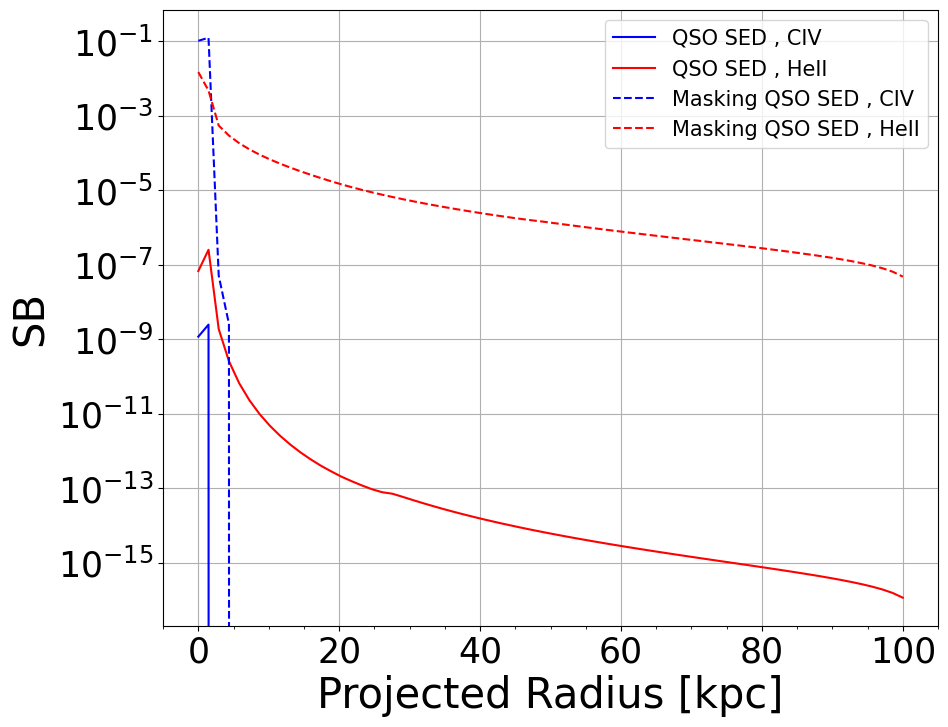

In [10]:
fig = plt.figure(1,figsize=(10,8))


Run = 'Q' #  Q : QSO_SED , Q_M : QSO_Masking_SED
atom = 'CIV' # atom : Lya , He II , CIV
LT = 'wo' # LT : Line transfer : W , WO
Lumin = 43 # Lum : 42 - 46
multi_factor = 1 # multiply factor : 1,5
Column_density_order = 21.0 # N_H = 19 - 24.5 (0.5) 
version = 4
# Ryd = 4
# plt.plot(RT_radius_vout_5 ,RT_SB_vout_5,'kx',ms=5, alpha = 0.5, label=r'w/ scattering, $v_{\rm out} = 500 \, \rm km/s$')


atom = 'CIV'
x,y = data_CLOUDY(Run,atom,Lumin,Column_density_order,multi_factor,version)[2:4]
plt.plot(x,y,'b-',label=f'QSO SED , {atom}')

atom = 'HeII'
x,y = data_CLOUDY(Run,atom,Lumin,Column_density_order,multi_factor,version)[2:4]
plt.plot(x,y,'r-',label=f'QSO SED , {atom}')

# atom = 'Lya'
# x,y = data_CLOUDY(Run,atom,LT,Lumin,Column_density_order,norm_v,norm)[2:4]
# plt.plot(x,y,'k-',label=f'{atom}')

Run = 'Q_M'
atom = 'CIV'
x,y = data_CLOUDY(Run,atom,Lumin,Column_density_order,multi_factor,version)[2:4]
plt.plot(x,y,'b--',label=f'Masking QSO SED , {atom}')

atom = 'HeII'
x,y = data_CLOUDY(Run,atom,Lumin,Column_density_order,multi_factor,version)[2:4]
plt.plot(x,y,'r--',label=f'Masking QSO SED , {atom}')

# atom = 'Lya'
# x,y = data_CLOUDY(Run,atom,LT,Lumin,Column_density_order,norm_v,norm)[2:4]

# plt.plot(x,y,'k--',label=f'{atom}')


# plt.xlim(-0.5,10)
plt.yscale('log')
plt.legend(fontsize=15)
plt.xlabel('Projected Radius [kpc]',fontsize=30)
plt.ylabel('SB',fontsize=30)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.minorticks_on()

plt.grid(True)


